In [1]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


# Install / import all libraries

In [3]:
# Install / import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#  Global style 
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#161616',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#cccccc',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'text.color':        '#eeeeee',
    'grid.color':        '#2a2a2a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#ffffff',
    'axes.labelsize':    11,
    'figure.titlesize':  15,
    'figure.titleweight':'bold',
    'font.family':       'DejaVu Sans',
    'legend.facecolor':  '#1e1e1e',
    'legend.edgecolor':  '#333333',
    'legend.fontsize':    9,
})

PALETTE   = ['#e8c97a', '#7eb8a4', '#c97b6b', '#8b9ed4', '#b87db8', '#78c4a8']
C_AMBER   = '#e8c97a'
C_TEAL    = '#7eb8a4'
C_CORAL   = '#c97b6b'
C_BLUE    = '#8b9ed4'
C_PURPLE  = '#b87db8'
C_GREEN   = '#78c4a8'



# Feature Engineering

In [5]:


df = pd.read_csv('../data/processed/cleaned_data.csv')

# Remove 'Unknown' rows for cleaner analysis
df_clean = df[~df['stress_level'].isin(['Unknown']) & ~df['platform'].isin(['Unknown'])].copy()

# Derived columns used throughout (Feature Engineering)
df_clean['age_group'] = pd.cut(df_clean['age'],
    bins=[14,18,24,30,36,44],
    labels=['15-18','19-24','25-30','31-36','37-44'])

df_clean['reels_bin'] = pd.cut(df_clean['reels_watch_time_hours'],
    bins=[0,1,2,3,4,6],
    labels=['<1h','1-2h','2-3h','3-4h','4-6h'])

df_clean['sleep_bin'] = pd.cut(df_clean['sleep_hours'],
    bins=[0,5,6,7,9],
    labels=['<5h','5-6h','6-7h','7h+'])

df_clean['screen_bin'] = pd.cut(df_clean['daily_screen_time_hours'],
    bins=[0,4,7,10,17],
    labels=['<4h','4-7h','7-10h','10h+'])

# Composite Cognitive Productivity Index (Index made to analyze the performance of the subject )
df_clean['CPI'] = (
    df_clean['attention_span_score'] +
    df_clean['focus_level'] +
    df_clean['task_completion_rate'] / 10
) / 3

# Reels watched of total screen time (%)
df_clean['reels_ratio_pct'] = (
    df_clean['reels_watch_time_hours'] / df_clean['daily_screen_time_hours'] * 100
)

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Clean subset  : {df_clean.shape[0]:,} rows (after removing 'Unknown' labels)")


 Dataset loaded: 8,926 rows × 10 columns
   Clean subset  : 8,779 rows (after removing 'Unknown' labels)


# Data Overview

In [6]:
# ── Basic info ────────────────────────────────────────────────────
print("=" * 60)
print("DATASET SHAPE:", df.shape)
print("=" * 60)
print(df.dtypes)
print()
print("COLUMN DESCRIPTIONS")
print("-" * 60)
desc = {
    'user_id':                 'Unique identifier for each user',
    'age':                     'Age in years (15–44)',
    'reels_watch_time_hours':  'Daily hours spent watching short-form reels',
    'daily_screen_time_hours': 'Total daily screen time across all apps',
    'sleep_hours':             'Average nightly sleep hours',
    'attention_span_score':    'Self-reported attention score (1–10)',
    'focus_level':             'Self-reported focus score (1–10)',
    'task_completion_rate':    'Percentage of tasks completed daily (0–100)',
    'stress_level':            'Categorical stress level (Low / Medium / High)',
    'platform':                'Primary short-form video platform used',
}
for col, d in desc.items():
    print(f"  {col:<28} → {d}")


DATASET SHAPE: (8926, 10)
user_id                      int64
age                        float64
reels_watch_time_hours     float64
daily_screen_time_hours    float64
sleep_hours                float64
attention_span_score       float64
focus_level                float64
task_completion_rate       float64
stress_level                   str
platform                       str
dtype: object

COLUMN DESCRIPTIONS
------------------------------------------------------------
  user_id                      → Unique identifier for each user
  age                          → Age in years (15–44)
  reels_watch_time_hours       → Daily hours spent watching short-form reels
  daily_screen_time_hours      → Total daily screen time across all apps
  sleep_hours                  → Average nightly sleep hours
  attention_span_score         → Self-reported attention score (1–10)
  focus_level                  → Self-reported focus score (1–10)
  task_completion_rate         → Percentage of tasks completed

##  Descriptive statistics (took only numerical columns)


In [9]:
num_cols = ['age','reels_watch_time_hours','daily_screen_time_hours',
            'sleep_hours','attention_span_score','focus_level','task_completion_rate']

stats_df = df_clean[num_cols].describe().T.round(3)
stats_df.columns = ['count','mean','std','min','25%','50%','75%','max']
display(stats_df.style.background_gradient(subset=['mean'], cmap='YlOrBr').background_gradient(subset=['std'],  cmap='Blues').format(precision=2))


,count,mean,std,min,25%,50%,75%,max
age,8779.00,29.57,8.67,15.00,22.00,30.00,37.00,44.00
reels_watch_time_hours,8779.00,3.02,1.54,0.50,1.70,2.91,4.29,6.00
daily_screen_time_hours,8779.00,7.73,2.80,2.00,5.59,7.80,9.93,16.43
sleep_hours,8779.00,6.47,1.50,1.46,5.22,6.50,7.74,9.00
attention_span_score,8779.00,5.51,2.59,1.00,3.26,5.53,7.75,10.00
focus_level,8779.00,5.49,2.59,1.00,3.27,5.46,7.77,10.00
task_completion_rate,8779.00,70.03,17.17,37.93,55.29,70.10,84.86,99.99


In [10]:
# ── Categorical distributions ─────────────────────────────────────
print("STRESS LEVEL")
print(df_clean['stress_level'].value_counts())
print()
print("PLATFORM")
print(df_clean['platform'].value_counts())


STRESS LEVEL
stress_level
Low       2937
Medium    2928
High      2914
Name: count, dtype: int64

PLATFORM
platform
Tiktok             2971
Instagram Reels    2963
Youtube Shorts     2845
Name: count, dtype: int64


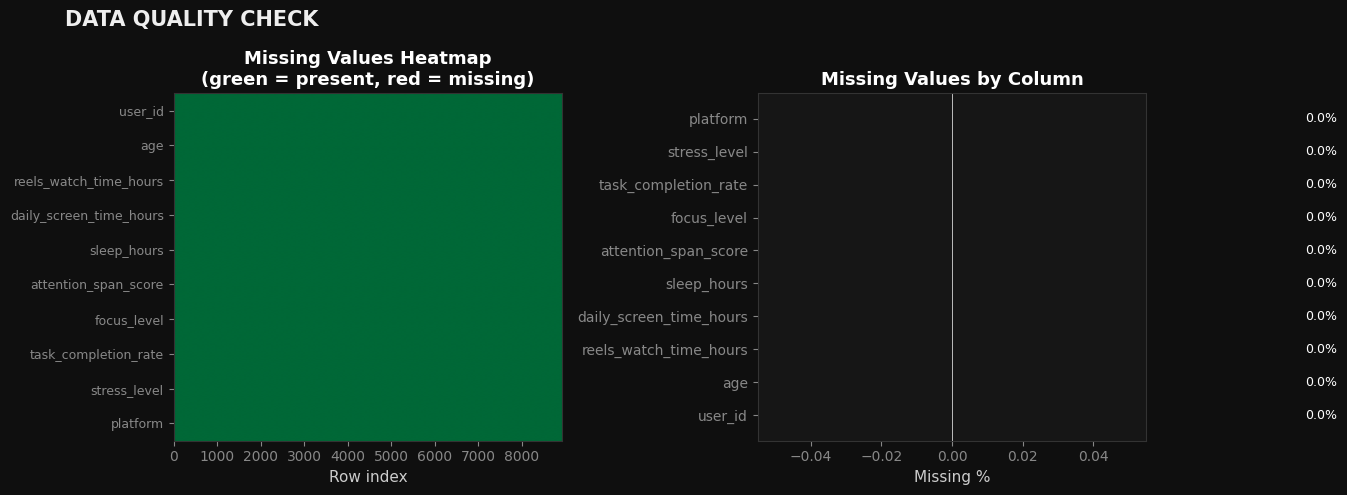

  No missing values in numeric columns. 73 'Unknown' in stress_level, 74 in platform — removed for analysis.


In [ ]:
# ── Missing values ──────────────────────────────────────────────── (Might be not useful to keep)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DATA QUALITY CHECK", x=0.05, ha='left')

# Missing heatmap
missing = df.isnull()
ax = axes[0]
im = ax.imshow(missing.T.astype(int), aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns, fontsize=9)
ax.set_xlabel("Row index")
ax.set_title("Missing Values Heatmap\n(green = present, red = missing)")

# Missing bar
missing_pct = (df.isnull().sum() / len(df) * 100)
ax2 = axes[1]
colors = [C_CORAL if v > 0 else C_TEAL for v in missing_pct.values]
bars = ax2.barh(missing_pct.index, missing_pct.values, color=colors, height=0.6)
ax2.set_xlabel("Missing %")
ax2.set_title("Missing Values by Column")
ax2.axvline(0, color='white', linewidth=0.5)
for bar, val in zip(bars, missing_pct.values):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='white')

plt.tight_layout()

plt.show()
print("  No missing values in numeric columns. 73 'Unknown' in stress_level, 74 in platform — removed for analysis.")


#  Outlier detection via IQR 


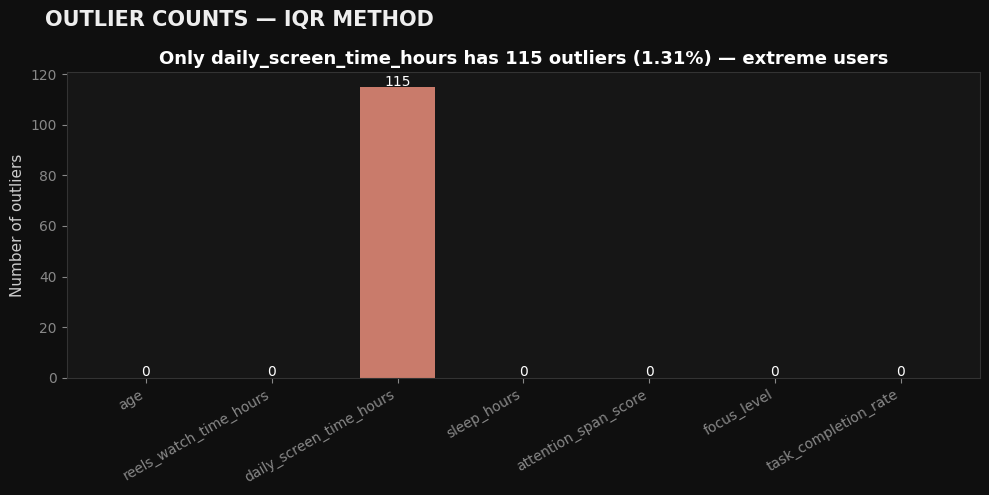

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("OUTLIER COUNTS — IQR METHOD", x=0.05, ha='left')

outlier_counts = {}
for col in num_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    outlier_counts[col] = n_out

cols_o = list(outlier_counts.keys())
vals_o = list(outlier_counts.values())
colors_o = [C_CORAL if v > 0 else C_TEAL for v in vals_o]
bars = ax.bar(cols_o, vals_o, color=colors_o, width=0.6)
ax.set_ylabel("Number of outliers")
ax.set_xticklabels(cols_o, rotation=30, ha='right')
for bar, v in zip(bars, vals_o):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha='center', fontsize=10, color='white')
ax.set_title("Only daily_screen_time_hours has 115 outliers (1.31%) — extreme users")

plt.tight_layout()

plt.show()


# Univariate Analysis   
Studying each variable individually — its distribution, shape, and spread.

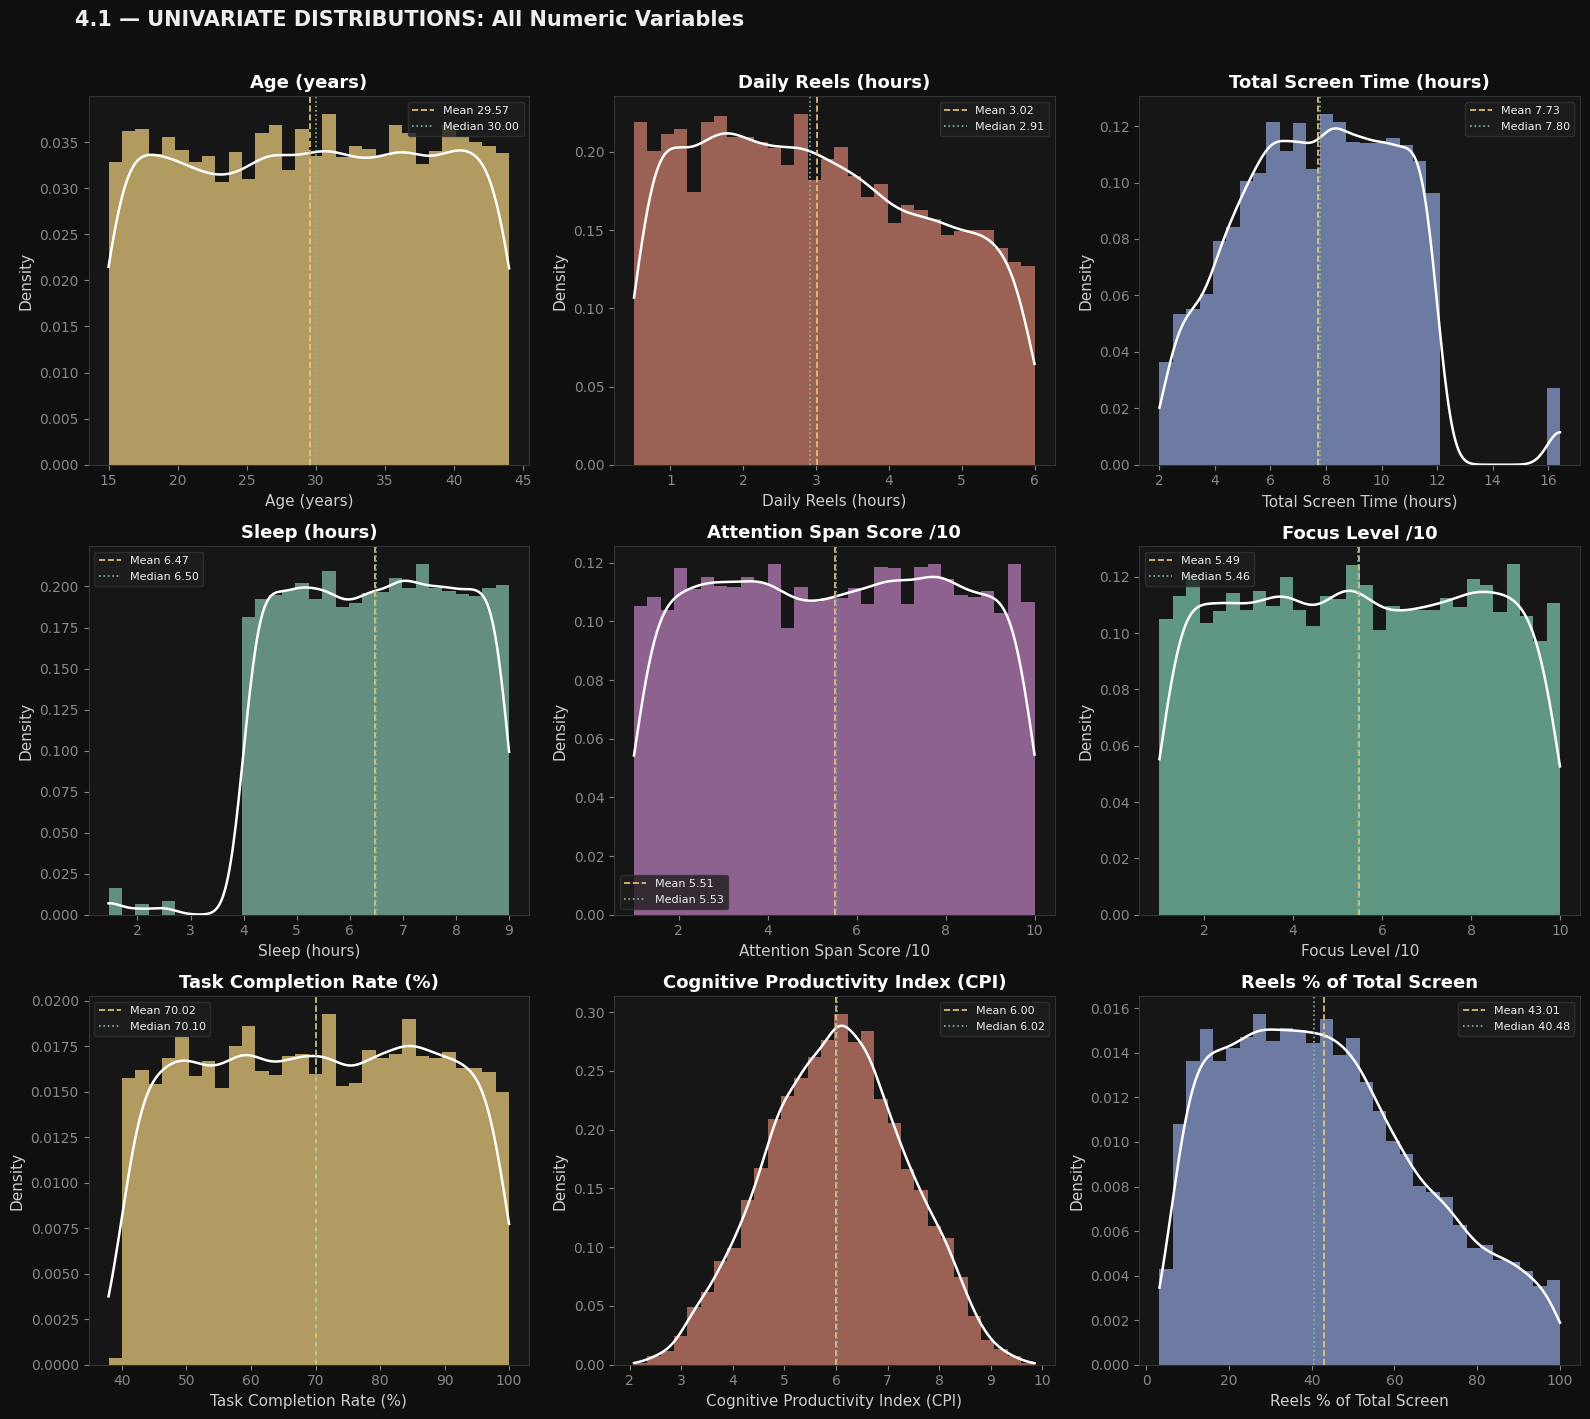

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("4.1 — UNIVARIATE DISTRIBUTIONS: All Numeric Variables", y=1.01, x=0.05, ha='left')

plot_configs = [
    ('age',                     'Age (years)',               C_AMBER),
    ('reels_watch_time_hours',  'Daily Reels (hours)',        C_CORAL),
    ('daily_screen_time_hours', 'Total Screen Time (hours)',  C_BLUE),
    ('sleep_hours',             'Sleep (hours)',              C_TEAL),
    ('attention_span_score',    'Attention Span Score /10',   C_PURPLE),
    ('focus_level',             'Focus Level /10',            C_GREEN),
    ('task_completion_rate',    'Task Completion Rate (%)',   C_AMBER),
    ('CPI',                     'Cognitive Productivity Index (CPI)', C_CORAL),
    ('reels_ratio_pct',         'Reels % of Total Screen',   C_BLUE),
]

for ax, (col, label, color) in zip(axes.flat, plot_configs):
    data = df_clean[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.75, density=True, edgecolor='none')
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color='white', linewidth=1.8)
    ax.axvline(data.mean(),   color=C_AMBER, linewidth=1.2, linestyle='--', label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color=C_TEAL,  linewidth=1.2, linestyle=':',  label=f'Median {data.median():.2f}')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()

plt.show()

# Box-and-Whisker Plots (spread + outliers) 


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("4.2 — BOX PLOTS: Spread & Outliers for All Numeric Variables", x=0.05, ha='left')

for ax, (col, label, color) in zip(axes.flat, plot_configs[:-1]):
    bp = ax.boxplot(df_clean[col].dropna(),
                    patch_artist=True, vert=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888', linewidth=1),
                    capprops=dict(color='#888', linewidth=1),
                    flierprops=dict(marker='o', color=color, alpha=0.3, markersize=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(label)
    ax.set_xticks([])
    mu  = df_clean[col].mean()
    med = df_clean[col].median()
    offset = (df_clean[col].max() - df_clean[col].min()) * 0.02 # Offset (+ / -) → pushes one label slightly up and the other down
    ax.text(1.35, mu + offset,  f'μ={mu:.2f}',  color=C_AMBER, fontsize=8, va='center')
    ax.text(1.35, med - offset, f'M={med:.2f}', color=C_TEAL,  fontsize=8, va='center')

plt.tight_layout()

plt.show()

In [ ]:
# ── 4.3  Categorical distributions (No Major distribution so might be not useful just to put on dashboard as the platform distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.3 — CATEGORICAL DISTRIBUTIONS", x=0.05, ha='left')

# Platform
plat_counts = df_clean['platform'].value_counts()
wedge_colors = [C_BLUE, C_TEAL, C_AMBER]
wedges, texts, autotexts = axes[0].pie(
    plat_counts.values, labels=plat_counts.index,
    colors=wedge_colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=2))
for at in autotexts: at.set_color('white'); at.set_fontsize(11)
for t  in texts:      t.set_color('#cccccc'); t.set_fontsize(10)
axes[0].set_title("Platform Distribution")

# Stress level
stress_counts = df_clean['stress_level'].value_counts().reindex(['Low','Medium','High'])
bar_colors = [C_TEAL, C_AMBER, C_CORAL]
bars = axes[1].bar(stress_counts.index, stress_counts.values,
                   color=bar_colors, width=0.55, edgecolor='none')
axes[1].set_title("Stress Level Distribution")
axes[1].set_ylabel("Number of Users")
for bar, v in zip(bars, stress_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'{v:,}({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=10, color='white')

plt.tight_layout()

plt.show()


In [ ]:
# ── 4.4  Skewness & Kurtosis summary table ────────────────────────
sk_df = pd.DataFrame({
    'Mean':     df_clean[num_cols].mean().round(3),
    'Std Dev':  df_clean[num_cols].std().round(3),
    'Skewness': df_clean[num_cols].skew().round(3),
    'Kurtosis': df_clean[num_cols].kurt().round(3),
    'Shape':    [('Slightly right-skewed' if s>0.2 else
                  'Slightly left-skewed'  if s<-0.2 else
                  'Approximately normal')
                 for s in df_clean[num_cols].skew()]
})

print("SKEWNESS & KURTOSIS SUMMARY")
print("(Skewness near 0 = symmetric | Kurtosis near 0 = normal tails)")
display(sk_df.style
    .applymap(lambda v: 'color: #e8c97a' if isinstance(v,float) and abs(v)>0.5 else '', subset=['Skewness'])
    .background_gradient(subset=['Kurtosis'], cmap='coolwarm'))

print()
print("Key insight: ALL variables have platykurtic distributions (kurtosis < 0)")
print("   → Flat, uniform-like distributions — data is evenly spread, not clustered around mean.")
print("   This is characteristic of uniformly-sampled survey data.")


# Bivariate Analysis

In [ ]:
# ── 5.1  Full Correlation Heatmap ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("5.1 — CORRELATION MATRIX: All Numeric Variables", x=0.05, ha='left')

corr = df_clean[num_cols + ['CPI','reels_ratio_pct']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, ax=ax, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size': 9})
ax.set_title("Lower triangle — Pearson correlation coefficients"
             "Values near ±1 = strong relationship | near 0 = no linear relationship")
plt.tight_layout()

plt.show()


In [ ]:
# ── 5.2  Scatter plots: Reels vs Cognitive Outcomes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("5.2 — SCATTER: Daily Reels Hours vs Cognitive Outcomes", x=0.05, ha='left')

outcomes = [
    ('attention_span_score', 'Attention Span Score', C_PURPLE),
    ('focus_level',          'Focus Level',          C_TEAL),
    ('task_completion_rate', 'Task Completion Rate (%)', C_AMBER),
]
sample = df_clean.sample(800, random_state=42)

for ax, (col, label, color) in zip(axes, outcomes):
    ax.scatter(sample['reels_watch_time_hours'], sample[col],
               alpha=0.25, color=color, s=12, edgecolors='none')
    # regression line
    m, b, r, p, se = stats.linregress(df_clean['reels_watch_time_hours'], df_clean[col])
    x_line = np.linspace(0.5, 6.0, 100)
    ax.plot(x_line, m*x_line + b, color='white', linewidth=2)
    ax.set_xlabel("Daily Reels Hours")
    ax.set_ylabel(label)
    ax.set_title(f"r = {r:.4f}  |  p = {p:.3f}{'Statistically significant' if p<0.05 else 'NOT significant'}")
    ax.text(0.05, 0.95, f"y = {m:.4f}x + {b:.3f}",
            transform=ax.transAxes, fontsize=9, color='#aaa', va='top')

plt.tight_layout()

plt.show()


In [ ]:
#Scatter: Sleep vs Cognitive Outcomes 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("5.3 — SCATTER: Sleep Hours vs Cognitive Outcomes", x=0.05, ha='left')

for ax, (col, label, color) in zip(axes, outcomes):
    ax.scatter(sample['sleep_hours'], sample[col],
               alpha=0.25, color=color, s=12, edgecolors='none')
    m, b, r, p, se = stats.linregress(df_clean['sleep_hours'], df_clean[col])
    x_line = np.linspace(1.5, 9.0, 100)
    ax.plot(x_line, m*x_line + b, color='white', linewidth=2)
    ax.set_xlabel("Sleep Hours")
    ax.set_ylabel(label)
    ax.set_title(f"r = {r:.4f}  |  p = {p:.3f}")
    ax.axvline(7, color=C_TEAL, linewidth=1, linestyle=':', alpha=0.7, label='7h mark')
    ax.axvline(6, color=C_CORAL, linewidth=1, linestyle=':', alpha=0.7, label='6h mark')
    ax.legend(fontsize=8)

plt.tight_layout()

plt.show()


In [ ]:
# Box plots: Stress level vs all outcomes 
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("5.4 — BOX PLOTS: Stress Level vs Cognitive Outcomes", x=0.05, ha='left')

stress_order = ['Low', 'Medium', 'High']
stress_colors = [C_TEAL, C_AMBER, C_CORAL]

for ax, (col, label, _) in zip(axes, outcomes):
    data_groups = [df_clean[df_clean['stress_level']==s][col].dropna() for s in stress_order]
    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888'),
                    capprops=dict(color='#888'),
                    flierprops=dict(marker='o', alpha=0.15, markersize=2))
    for patch, color in zip(bp['boxes'], stress_colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(stress_order)
    ax.set_ylabel(label)
    ax.set_title(label)
    # ANOVA test
    f_val, p_val = stats.f_oneway(*data_groups)
    ax.text(0.05, 0.97, f"ANOVA: F={f_val:.3f}, p={p_val:.4f}",
            transform=ax.transAxes, fontsize=8, color='#aaa', va='top')

plt.tight_layout()

plt.show()
print(" ANOVA: if p < 0.05, stress level significantly affects the outcome.")
print("There is no statistically significant difference in mean cognitive performance across stress levels.")


In [ ]:
# Box plots: Platform vs Reels / Outcomes 
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("5.5 — BOX PLOTS: Platform vs Behavioral & Cognitive Variables", x=0.05, ha='left')

plat_order  = ['Tiktok', 'Instagram Reels', 'Youtube Shorts']
plat_colors = [C_CORAL, C_BLUE, C_AMBER]
plat_vars   = [
    ('reels_watch_time_hours', 'Daily Reels (h)'),
    ('attention_span_score',   'Attention Score'),
    ('focus_level',            'Focus Level'),
    ('task_completion_rate',   'Task Completion (%)'),
]

for ax, (col, label) in zip(axes, plat_vars):
    data_groups = [df_clean[df_clean['platform']==p][col] for p in plat_order]
    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#888'),
                    capprops=dict(color='#888'),
                    flierprops=dict(marker='o', alpha=0.1, markersize=2))
    for patch, c in zip(bp['boxes'], plat_colors):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(['TikTok','Instagram','YT Shorts'], rotation=15, fontsize=9)
    ax.set_title(label)
    f_val, p_val = stats.f_oneway(*data_groups)
    ax.text(0.05, 0.97, f"p={p_val:.4f}", transform=ax.transAxes, fontsize=8, color='#aaa', va='top')

plt.tight_layout()

plt.show()
print("No major insights")

In [ ]:
# ── 5.6  Bar plots: Reels consumption bin vs cognitive outcomes ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("5.6 — MEAN SCORES BY DAILY REELS CONSUMPTION TIER", x=0.05, ha='left')

reels_bins  = ['<1h','1-2h','2-3h','3-4h','4-6h']
bin_colors  = [C_TEAL, C_GREEN, C_AMBER, C_CORAL, '#e87a7a']

for ax, (col, label, _) in zip(axes, outcomes):
    means = [df_clean[df_clean['reels_bin']==b][col].mean() for b in reels_bins]
    bars  = ax.bar(reels_bins, means, color=bin_colors, width=0.6, edgecolor='none')
    ax.set_xlabel("Daily Reels Consumption")
    ax.set_ylabel(f"Mean {label}")
    ax.set_title(label)
    ymin = min(means) * 0.99
    ax.set_ylim(ymin, max(means) * 1.01)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', fontsize=9, color='white')

plt.tight_layout()

plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("5.7 — AGE GROUP vs REELS CONSUMPTION & ATTENTION SCORE", x=0.05, ha='left')

age_groups = ['15-18','19-24','25-30','31-36','37-44']
age_colors = [C_CORAL, C_AMBER, C_TEAL, C_BLUE, C_PURPLE]

for ax, (col, label, _) in zip(axes, [outcomes[0], ('reels_watch_time_hours','Daily Reels (h)', C_CORAL)]):
    means  = [df_clean[df_clean['age_group']==g][col].mean() for g in age_groups]
    stds   = [df_clean[df_clean['age_group']==g][col].std()  for g in age_groups]
    bars   = ax.bar(age_groups, means, color=age_colors, width=0.55, yerr=stds,
                    error_kw=dict(ecolor='#888', capsize=4, linewidth=1), capsize=4)
    ax.set_xlabel("Age Group")
    ax.set_ylabel(label)
    ax.set_title(label)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.2f}', ha='center', fontsize=9, color='white')

plt.tight_layout()

plt.show()

In [ ]:
#   Violin plots: Sleep bin vs Attention & Focus 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("5.8 — VIOLIN PLOTS: Sleep Quality vs Attention & Focus (full distribution shape)", x=0.05, ha='left')

sleep_bins   = ['<5h','5-6h','6-7h','7h+']
sleep_colors = [C_CORAL, C_AMBER, C_TEAL, C_BLUE]

for ax, (col, label, _) in zip(axes, outcomes[:2]):
    data_groups = [df_clean[df_clean['sleep_bin']==b][col].dropna().values for b in sleep_bins]
    parts = ax.violinplot(data_groups, positions=range(len(sleep_bins)),
                          showmedians=True, showextrema=True)
    for i, (body, color) in enumerate(zip(parts['bodies'], sleep_colors)):
        body.set_facecolor(color); body.set_alpha(0.65)
    parts['cmedians'].set_color('white')
    parts['cmaxes'].set_color('#666'); parts['cmins'].set_color('#666')
    parts['cbars'].set_color('#444')
    ax.set_xticks(range(len(sleep_bins))); ax.set_xticklabels(sleep_bins)
    ax.set_xlabel("Sleep Duration")
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()

plt.show()


In [ ]:
# Reels Ratio vs CPI scatter ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("5.9 — REELS SHARE OF TOTAL SCREEN TIME vs Cognitive Productivity Index (CPI)", x=0.05, ha='left')

scatter = ax.scatter(df_clean['reels_ratio_pct'], df_clean['CPI'],
                     c=df_clean['attention_span_score'],
                     cmap='plasma', alpha=0.35, s=10, edgecolors='none')
cb = plt.colorbar(scatter, ax=ax, fraction=0.03)
cb.set_label('Attention Score', color='#ccc')
cb.ax.yaxis.set_tick_params(color='#888')

m, b, r, p, _ = stats.linregress(df_clean['reels_ratio_pct'], df_clean['CPI'])
x_line = np.linspace(0, 100, 200)
ax.plot(x_line, m*x_line + b, color='white', linewidth=2, label=f'r={r:.4f}')
ax.set_xlabel("Reels % of Total Screen Time")
ax.set_ylabel("CPI (Cognitive Productivity Index)")
ax.set_title(f"Pearson r = {r:.4f}  |  p = {p:.4f}")
ax.legend()

plt.tight_layout()

plt.show()


# MultiVariate Analysis

In [ ]:
# ── 6.1  Pair Plot (mini scatter matrix) ─────────────────────────
import seaborn as sns

key_cols = ['reels_watch_time_hours','sleep_hours',
            'attention_span_score','focus_level','task_completion_rate']

sample_pair = df_clean.sample(1200, random_state=42)

g = sns.PairGrid(sample_pair[key_cols + ['stress_level']],
                 hue='stress_level', hue_order=['Low','Medium','High'],
                 palette={'Low': C_TEAL, 'Medium': C_AMBER, 'High': C_CORAL},
                 diag_sharey=False)
g.map_upper(sns.scatterplot, alpha=0.25, s=8, edgecolor='none')
g.map_lower(sns.kdeplot, alpha=0.5, levels=4)
g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
g.add_legend()

for ax in g.axes.flat:
    ax.set_facecolor('#161616')
g.figure.set_facecolor('#0f0f0f')
g.figure.suptitle("6.1 — PAIR PLOT: Key Variables coloured by Stress Level",
                  y=1.01, x=0.05, ha='left', color='white', fontsize=13, fontweight='bold')

plt.show()


In [ ]:
# ── 6.2  Heatmap: Age group × Reels bin → Mean Attention ─────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("6.2 — HEATMAPS: Age × Reels Consumption & Stress × Sleep → Cognitive Outcomes", x=0.05, ha='left')

# Heatmap 1: age_group x reels_bin -> attention
pivot1 = df_clean.groupby(['age_group','reels_bin'], observed=True)['attention_span_score'].mean().unstack()
sns.heatmap(pivot1, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#0f0f0f',
            vmin=5.0, vmax=6.0, annot_kws={'size': 10})
axes[0].set_title("Mean Attention Score Age Group × Daily Reels Consumption")
axes[0].set_xlabel("Daily Reels Consumption Tier")
axes[0].set_ylabel("Age Group")

# Heatmap 2: stress x sleep_bin -> CPI
pivot2 = df_clean.groupby(['stress_level','sleep_bin'], observed=True)['CPI'].mean().unstack()
pivot2 = pivot2.reindex(['Low','Medium','High'])
sns.heatmap(pivot2, ax=axes[1], annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size': 10})
axes[1].set_title("Mean CPI Stress Level × Sleep Duration")
axes[1].set_xlabel("Sleep Duration Bin")
axes[1].set_ylabel("Stress Level")

plt.tight_layout()

plt.show()
print(" 19-24 + heavy reels (3-4h) has the LOWEST attention: 5.33")
print("   37-44 + heavy reels (4-6h) has the HIGHEST attention: 5.70")


In [ ]:
# ── 6.3  Stacked bar: Platform × Stress level composition ─────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("6.3 — STACKED BAR: Platform × Stress Level Composition", x=0.05, ha='left')

ct = pd.crosstab(df_clean['platform'], df_clean['stress_level'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct[['Low','Medium','High']]

bottom = np.zeros(len(ct_pct))
colors_stress = [C_TEAL, C_AMBER, C_CORAL]
for col, color in zip(['Low','Medium','High'], colors_stress):
    bars = ax.bar(ct_pct.index, ct_pct[col], bottom=bottom,
                  color=color, label=col, width=0.5)
    for bar, b, v in zip(bars, bottom, ct_pct[col]):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    bottom += ct_pct[col].values

ax.set_ylabel("Percentage of Users (%)")
ax.set_title("Stress distribution is nearly IDENTICAL across all three platforms")
ax.legend(title='Stress Level', loc='upper right')
ax.set_ylim(0, 105)

plt.tight_layout()

plt.show()


In [ ]:
# ── 6.5  Grouped bar: Age × Platform → Mean Reels ────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("6.5 — GROUPED BAR: Age Group × Platform → Mean Daily Reels Consumption", x=0.05, ha='left')

age_groups = ['15-18','19-24','25-30','31-36','37-44']
platforms  = ['Tiktok','Instagram Reels','Youtube Shorts']
plat_colors_g = [C_CORAL, C_BLUE, C_AMBER]
x = np.arange(len(age_groups))
width = 0.26

for i, (plat, color) in enumerate(zip(platforms, plat_colors_g)):
    means = [df_clean[(df_clean['age_group']==g) & (df_clean['platform']==plat)]
             ['reels_watch_time_hours'].mean() for g in age_groups]
    bars = ax.bar(x + i*width, means, width=width, label=plat, color=color, edgecolor='none')
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, color='white')

ax.set_xticks(x + width)
ax.set_xticklabels(age_groups)
ax.set_xlabel("Age Group")
ax.set_ylabel("Mean Daily Reels (hours)")
ax.set_title("19-24 age group is the heaviest consumer on ALL three platforms")
ax.legend(title='Platform')

plt.tight_layout()

plt.show()
    

In [ ]:
# ── 6.6  FacetGrid: CPI distribution by Stress × Platform ─────────
g = sns.FacetGrid(df_clean, row='stress_level', col='platform',
                  hue='stress_level',
                  palette={'Low': C_TEAL, 'Medium': C_AMBER, 'High': C_CORAL},
                  height=3, aspect=1.2, sharey=False)
g.map_dataframe(sns.histplot, x='CPI', bins=20, alpha=0.75, kde=True)
g.set_axis_labels("CPI Score", "Count")
g.set_titles(row_template="Stress: {row_name}", col_template="{col_name}")
g.add_legend()

for ax in g.axes.flat:
    ax.set_facecolor('#161616')
g.figure.set_facecolor('#0f0f0f')
g.figure.suptitle("6.6 — FACET GRID: CPI Distribution by Stress Level & Platform",
                  y=1.02, x=0.05, ha='left', color='white', fontsize=12, fontweight='bold')


plt.show()


In [ ]:
# ── 6.7  Risk Segment Matrix ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("6.7 — RISK SEGMENTATION MATRIX", x=0.05, ha='left')

# Segment definition
def segment(row):
    high_reels = row['reels_watch_time_hours'] > 3
    low_sleep  = row['sleep_hours'] < 6
    if high_reels and low_sleep:   return 'Danger Zone\n(High Reels + Low Sleep)'
    elif high_reels:               return 'Reels at Risk\n(High Reels only)'
    elif low_sleep:                return 'Sleep Deprived\n(Low Sleep only)'
    else:                          return 'Safe Zone\n(Healthy habits)'

df_clean['segment'] = df_clean.apply(segment, axis=1)
seg_counts = df_clean['segment'].value_counts()
seg_order  = [
    'Safe Zone\n(Healthy habits)',
    'Reels at Risk\n(High Reels only)',
    'Sleep Deprived\n(Low Sleep only)',
    'Danger Zone\n(High Reels + Low Sleep)'
]
seg_colors = [C_TEAL, C_AMBER, C_BLUE, C_CORAL]

# Pie
wedges, texts, autotexts = axes[0].pie(
    [seg_counts.get(s, 0) for s in seg_order],
    labels=seg_order, colors=seg_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=2))
for at in autotexts: at.set_color('white'); at.set_fontsize(10); at.set_fontweight('bold')
for t  in texts:     t.set_color('#cccccc'); t.set_fontsize(8)
axes[0].set_title("User Segment Distribution")

# Mean CPI per segment
seg_cpi = [df_clean[df_clean['segment']==s]['CPI'].mean() for s in seg_order]
bars = axes[1].barh(seg_order, seg_cpi, color=seg_colors, height=0.5)
axes[1].set_xlabel("Mean CPI Score")
axes[1].set_title("Mean CPI by Risk Segment")
axes[1].axvline(df_clean['CPI'].mean(), color='white', linewidth=1,
                linestyle='--', label=f"Overall mean {df_clean['CPI'].mean():.3f}")
axes[1].legend()
for bar, v in zip(bars, seg_cpi):
    axes[1].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=10, color='white')

plt.tight_layout()

plt.show()

seg_summary = df_clean.groupby('segment')['CPI'].agg(['mean','count']).round(3)
seg_summary.columns = ['Mean CPI', 'User Count']
seg_summary['% of Users'] = (seg_summary['User Count'] / len(df_clean) * 100).round(1)
print(seg_summary.sort_values('Mean CPI', ascending=False)) 

In [ ]:
# ── 6.8  Cumulative Distribution (ECDF): Reels watch time ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("6.8 — ECDF: Cumulative Distribution of Reels & Screen Time", x=0.05, ha='left')

for ax, (col, label, color) in zip(axes, [
    ('reels_watch_time_hours', 'Daily Reels (hours)', C_CORAL),
    ('daily_screen_time_hours','Total Screen Time (hours)', C_BLUE)]):
    sorted_data = np.sort(df_clean[col].dropna())
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    ax.plot(sorted_data, cdf, color=color, linewidth=2)
    ax.fill_between(sorted_data, cdf, alpha=0.15, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel("Cumulative proportion of users")
    ax.set_title(f"ECDF — {label}")
    ax.axhline(0.5,  color='#888', linestyle='--', linewidth=1, label='50th percentile')
    ax.axhline(0.75, color='#666', linestyle=':', linewidth=1, label='75th percentile')
    ax.axhline(0.9,  color='#555', linestyle=':', linewidth=1, label='90th percentile')
    ax.legend(fontsize=8)
    # Annotate key thresholds
    for pct in [0.5, 0.75, 0.9]:
        val = np.percentile(sorted_data, pct*100)
        ax.annotate(f'{val:.1f}h', xy=(val, pct),
                    xytext=(val + 0.3, pct - 0.05),
                    color='#ccc', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='#888', lw=0.8))

plt.tight_layout()

plt.show()
print(" 50% of users watch MORE than 2.9h of reels daily")
print("   90% of users watch MORE than 1.0h of reels daily")


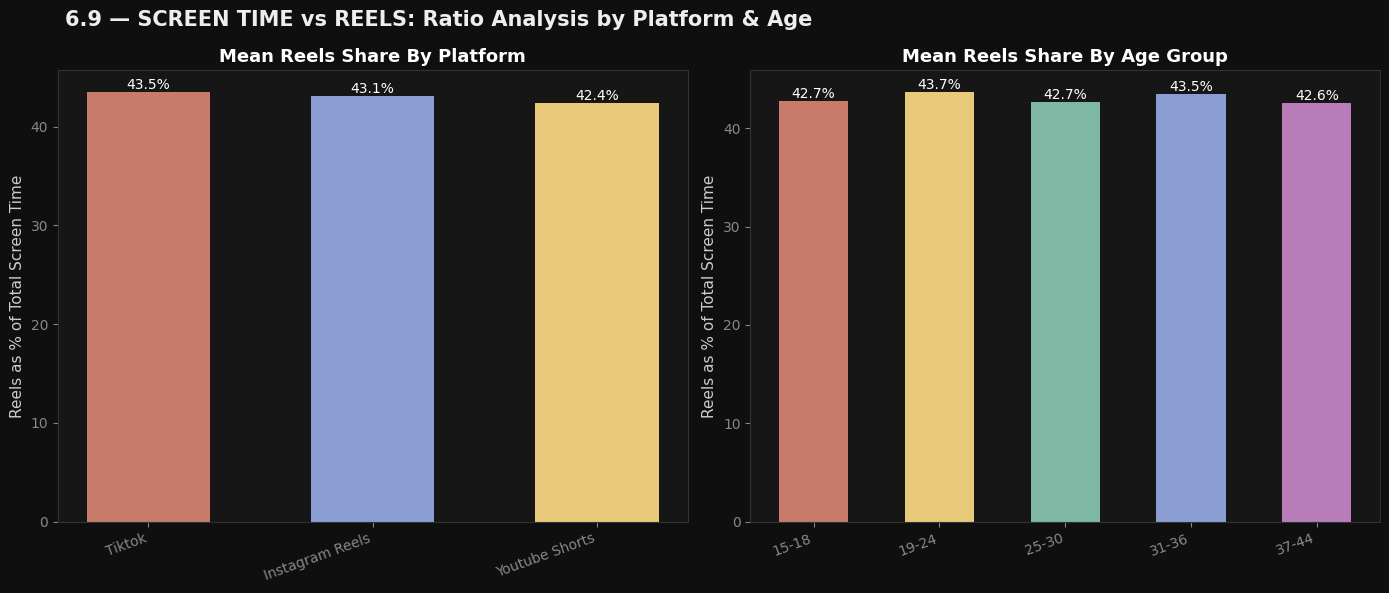

In [14]:
# ── 6.9  Correlation: Screen time components breakdown ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("6.9 — SCREEN TIME vs REELS: Ratio Analysis by Platform & Age", x=0.05, ha='left')

# Reels ratio by platform
for ax, (group_col, group_order, group_colors, title) in zip(axes, [
    ('platform',  ['Tiktok','Instagram Reels','Youtube Shorts'], [C_CORAL, C_BLUE, C_AMBER], 'By Platform'),
    ('age_group', ['15-18','19-24','25-30','31-36','37-44'],     [C_CORAL,C_AMBER,C_TEAL,C_BLUE,C_PURPLE], 'By Age Group'),
]):
    means = [df_clean[df_clean[group_col]==g]['reels_ratio_pct'].mean() for g in group_order]
    bars  = ax.bar(group_order, means, color=group_colors, width=0.55)
    ax.set_ylabel("Reels as % of Total Screen Time")
    ax.set_title(f"Mean Reels Share {title}")
    ax.set_xticklabels(group_order, rotation=20, ha='right')
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', fontsize=10, color='white')

plt.tight_layout()

plt.show()
